# Experiment 9 — embedded / low-resource footprint of the streaming filters

The streaming estimators (`EACFilter`, `LSIFilter`) are the only part of dtfit meant for
*online* deployment, and the natural place to ask the hardware question raised by the GPS
experiment: **can this run on the kind of microcontroller you would bolt to a GPS module?**
(Arduino / STM32 / ESP32 class.)

Three things decide that, and we measure each honestly:

1. **Per-sample latency** — the recurrence is O(1) in history; how many µs does one
   `partial_fit` cost, and therefore how many samples/second can one core sustain? (A GPS fix
   arrives at ~1–10 Hz, so there is enormous headroom.)
2. **State memory** — the bytes that must persist between samples. This is the real constraint
   on a 2 KB-SRAM part, and it is *tiny and fixed* (a ring buffer + a few small matrices),
   independent of how long the stream runs.
3. **What actually ports.** The reference here is Python + NumPy + a compiled SymPy callable —
   none of which runs on a microcontroller. What ports is the **recurrence**: a fixed-size C
   struct and a handful of small matrix ops (the integration kernels are already C in
   `dtfit._native`). So the latency below is the desktop reference for the *algorithm shape*;
   the memory figure is the deployable C-struct size, computed exactly; and the MCU table
   estimates the fit of that struct against common parts. We do not pretend NumPy runs on an AVR.

**The honest framing:** NumPy does not run on an AVR, so latency here is the desktop reference
for the algorithm shape, while the memory figure is the exact C-struct size that does deploy.
Latency numbers vary by machine — that is expected.

All heavy logic lives in `backend.py` (`B.*`); this notebook is a thin, rerunnable presentation
layer over the exact measurement + accounting code. Run **Setup** first, then any section.

## Setup
Imports, configuration knobs, and helpers. Re-run after changing the config. The package name
starts with a digit, so the backend is imported via `importlib`.

In [1]:
import importlib
from pathlib import Path

import numpy as np
import pandas as pd

# The experiment backend -- single source of truth for the latency timers,
# state-size arithmetic and MCU-fit model. Imported via importlib because the
# package name (09_embedded_footprint) starts with a digit.
B = importlib.import_module(
    "dtfit_experimental.experiments.cases.09_embedded_footprint.backend")
from dtfit_experimental.experiments.common import fmt

%matplotlib inline
import matplotlib.pyplot as plt

FIG = Path(B.__file__).parent / "figures"          # a saved copy of every figure
FIG.mkdir(exist_ok=True)

# ---- configuration (edit + re-run) ----------------------------------------- #
# Defaults are the old `quick=True` reductions so the notebook runs in a few
# minutes; scale up by raising N_TIMED / CF_TIMED for tighter latency estimates.
N_TIMED   = 1500     # timed steady-state updates per latency measurement (5000 = full)
CF_TIMED  = 120      # timed curve_fit refits (400 = full); curve_fit is slow, keep small
RATE_HZ   = 10       # GPS epoch rate the MCU must keep up with

pd.set_option("display.float_format", lambda v: f"{v:.2f}")
print(f"latency: {N_TIMED} timed updates | curve_fit: {CF_TIMED} refits | "
      f"MCU budget: {RATE_HZ} Hz ({1e3/RATE_HZ:.0f} ms/epoch)")
print(f"figures saved to: {FIG}")

latency: 1500 timed updates | curve_fit: 120 refits | MCU budget: 10 Hz (100 ms/epoch)
figures saved to: F:\repos\fallen-traces\science-nonline\packages\dtfit-experimental\src\dtfit_experimental\experiments\cases\09_embedded_footprint\figures


## 1. Per-sample latency & throughput (all package filters)

Mean wall-clock cost of one steady-state update on this desktop (warmed window, `N_TIMED` timed
updates), and the sustainable sample rate it implies, for every online estimator in the package
plus the Kalman reference. The recurrence is O(1) in stream length, so this is flat for the
whole stream. A GPS fix arrives at ~1–10 Hz; the headroom is several orders of magnitude.

The configurations under test (`B.CONFIGS`): a CA quadratic (GPS axis), a damped sine (control
ID), and a linear range smoother — plus the Legendre `LSIFilter` and the CA Kalman reference.

In [2]:
from dtfit.streaming import EACFilter, LSIFilter

lat_rows = []
lat_by_cfg = {}
for label, expr, var, p0, kw, n, w in B.CONFIGS:
    def make(expr=expr, var=var, p0=p0, kw=kw):
        return EACFilter(expr, var, p0=p0, **kw)
    us = B.measure_latency(make, n_warm=w + 5, n_timed=N_TIMED)
    lat_by_cfg[label] = us
    lat_rows.append(["EACFilter", label, f"n={n}, W={w}",
                     fmt(us, "{:.1f}"), fmt(1e6 / us, "{:,.0f}")])

# LSIFilter (the orthogonal-spectrum sibling): more observability per window at
# the cost of an order+1 projection -- so a bit heavier per step.
lsi_us = B.measure_latency(
    lambda: LSIFilter("A*exp(-d*t)*sin(w*t)", "t", p0=[1.0, 0.1, 1.0], window_size=50,
                      order=5, q_diag=[1e-2] * 3, r=1.0),
    n_warm=55, n_timed=N_TIMED)
lat_by_cfg["LSIFilter"] = lsi_us
lat_rows.append(["LSIFilter", "damped sine", "n=3, W=50, ord=5",
                 fmt(lsi_us, "{:.1f}"), fmt(1e6 / lsi_us, "{:,.0f}")])

# Kalman reference (no window, no integral -- the leanest update).
kf_us = B.measure_kalman_latency(n_timed=N_TIMED)
lat_by_cfg["Kalman (CA)"] = kf_us
lat_rows.append(["CA Kalman (3-axis)", "reference", "dim=3",
                 fmt(kf_us, "{:.2f}"), fmt(1e6 / kf_us, "{:,.0f}")])

S1 = pd.DataFrame(lat_rows, columns=["estimator", "config", "size", "µs / update",
                                     "max samples/s (1 core)"]).set_index("estimator")
S1

,config,size,µs / update,max samples/s (1 core)
estimator,,,,
EACFilter,CA quadratic (GPS axis),"n=3, W=15",39.8,"25,138"
EACFilter,damped sine (control ID),"n=3, W=50",49.8,"20,094"
EACFilter,linear (range smoother),"n=2, W=20",43.8,"22,833"
LSIFilter,damped sine,"n=3, W=50, ord=5",44.9,"22,282"
CA Kalman (3-axis),reference,dim=3,30.66,"32,620"


`FilterBank` is just K of these run together (one per axis/channel/satellite), so its cost and
memory are K× a single filter — e.g. the 3-axis GPS tracker is 3 `EACFilter`s. The Legendre
filter is the heaviest per step (it projects onto `order+1` orthogonal moments for extra
observability); the Kalman is the lightest (no window, no integral). All sit far under any
real-time budget.

## 2. Resident state memory — the deployable C struct

The bytes that must persist between samples. For a minimal C port this is a **fixed-size,
no-malloc struct**: the `t,y` ring buffer (2·W words), the estimate `p` (n), covariance `P`
(n²), process-noise diagonal `Q` (n), and ~8 detector/measurement scalars — i.e.
`2W + n² + 2n + 8` words. It does **not grow with stream length** (the defining property of a
real-time estimator). Shown in float64 (the reference) and float32 (a natural embedded choice;
the integration kernels carry fine at single precision for these window sizes).

In [3]:
mem_rows = []
for label, expr, var, p0, kw, n, w in B.CONFIGS:
    words = B.state_doubles_eac(n, w)
    mem_rows.append([
        label, f"n={n}, W={w}", f"{words}",
        f"{B.state_bytes(n, w, 8):,} B", f"{B.state_bytes(n, w, 4):,} B",
        f"~{B.approx_flops_per_update(n, w):,}"])

S2 = pd.DataFrame(mem_rows, columns=["config", "size", "state words", "float64",
                                     "float32", "FLOPs/update"]).set_index("config")
S2

,size,state words,float64,float32,FLOPs/update
config,,,,,
CA quadratic (GPS axis),"n=3, W=15",53,424 B,212 B,~527
damped sine (control ID),"n=3, W=50",123,984 B,492 B,"~1,647"
linear (range smoother),"n=2, W=20",56,448 B,224 B,~388


**`LSIFilter` (the other filter).** Its *mutable* RAM state has the same shape — `2W + n² + n + 9`
words — so its **SRAM** footprint is essentially the same as the area filter. It additionally
precomputes **read-only** projection/quadrature tables (the orthogonal-basis Vandermonde +
Gauss-Legendre nodes); those are constants that belong in **flash/PROGMEM**, not SRAM. So it
buys extra observability (an `order+1`-dimensional measurement) for more flash and a little more
compute — not more RAM. **The CA Kalman is the leanest of all** because it keeps **no history
window** — the honest cost of dtfit's integral measurement is exactly that window buffer.

The cell below quantifies these (LSI mutable RAM + flash tables, Kalman mutable words) and the
*Python-object* footprint — the interpreter/NumPy overhead a C port removes, reported only for
contrast. **It is not the embedded number.**

In [4]:
lsi_n, lsi_w, lsi_ord = 3, 50, 5
lsi_ram = B.state_doubles_lsi_ram(lsi_n, lsi_w)
lsi_const = B.const_doubles_lsi(lsi_n, lsi_w, lsi_ord)
kal_words = B.state_doubles_kalman(3)

# Python-object footprint of one warmed EACFilter (the GPS-axis config).
_, expr0, var0, p00, kw0, _, w0 = B.CONFIGS[0]
py_bytes = B.measure_resident_python(
    lambda: EACFilter(expr0, var0, p0=p00, **kw0), n_warm=w0 + 5)

S2b = pd.Series({
    f"LSIFilter mutable RAM (n={lsi_n}, W={lsi_w}, words)": lsi_ram,
    "LSIFilter mutable RAM (float32 bytes)": lsi_ram * 4,
    "LSIFilter read-only tables (flash words)": lsi_const,
    "CA Kalman mutable words (3-axis)": kal_words,
    "CA Kalman (float32 bytes, 3-axis)": kal_words * 4,
    "one Python EACFilter object (KB)": round(py_bytes / 1024, 1),
    "...vs algorithmic state (bytes)": B.state_bytes(3, 15, 8),
}, name="value")
S2b.to_frame()

,value
"LSIFilter mutable RAM (n=3, W=50, words)",121.00
LSIFilter mutable RAM (float32 bytes),484.00
LSIFilter read-only tables (flash words),440.00
CA Kalman mutable words (3-axis),36.00
"CA Kalman (float32 bytes, 3-axis)",144.00
one Python EACFilter object (KB),86.20
...vs algorithmic state (bytes),424.00


One *Python* filter object (warmed) holds hundreds of times the algorithmic state in
interpreter/NumPy objects. That gap is pure Python/NumPy overhead and is exactly what a C port
removes; it is **not** what runs on the MCU.

## 3. Fit on real microcontrollers (3-axis GPS tracker)

A full 3-axis tracker is three independent filters: the float32 / float64 state and FLOPs per
GPS epoch are reported below. Whether a part fits is a **memory** question (the state must live
in SRAM alongside everything else) far more than a compute one — even a pessimistic soft-float
estimate keeps the per-epoch compute orders of magnitude under the budget. Compute time is a
rough estimate (effective MFLOP/s, soft-float-penalised where there is no FPU); memory fit is
exact.

In [5]:
n, w = 3, 15
per_axis64, per_axis32 = B.state_bytes(n, w, 8), B.state_bytes(n, w, 4)
track64, track32 = per_axis64 * 3, per_axis32 * 3        # 3 axes
flops = B.approx_flops_per_update(n, w) * 3              # whole 3-axis update
budget_ms = 1e3 / RATE_HZ
print(f"3-axis tracker state: {track32:,} B (f32) / {track64:,} B (f64); "
      f"~{flops:,} FLOPs/epoch; budget {budget_ms:.0f} ms/epoch")

mcu_rows = []
for name, sram, mhz, fpu, mflops in B.MCUS:
    compute_ms = flops / (mflops * 1e6) * 1e3
    fits32 = "✓" if track32 < sram * 0.5 else ("tight" if track32 < sram else "✗")
    keeps_up = "✓" if compute_ms < budget_ms * 0.5 else (
        "tight" if compute_ms < budget_ms else "✗")
    mcu_rows.append([
        name, f"{sram // 1024} KB", f"{mhz}", "yes" if fpu else "no (soft)",
        f"{track32:,} B \u2192 {fits32}", f"~{compute_ms:.2f} ms \u2192 {keeps_up}"])

S3 = pd.DataFrame(mcu_rows, columns=[
    "MCU", "SRAM", "MHz", "FPU", "state f32 (fits if <50% SRAM)",
    f"compute/epoch (<{budget_ms:.0f} ms budget)"]).set_index("MCU")
S3

3-axis tracker state: 636 B (f32) / 1,272 B (f64); ~1,581 FLOPs/epoch; budget 100 ms/epoch


,SRAM,MHz,FPU,state f32 (fits if <50% SRAM),compute/epoch (<100 ms budget)
MCU,,,,,
AVR ATmega328 (Uno/Nano),2 KB,16,no (soft),636 B → ✓,~31.62 ms → ✓
ARM Cortex-M0+ (SAMD21/Zero),32 KB,48,no (soft),636 B → ✓,~5.27 ms → ✓
ARM Cortex-M4F (STM32F4/Teensy),192 KB,168,yes,636 B → ✓,~0.05 ms → ✓
ESP32 (Xtensa LX6 FPU),520 KB,240,yes,636 B → ✓,~0.04 ms → ✓


## 4. Comparison with existing methods

How the streaming filters stack up against the alternatives you might deploy for the same online
job. The deciding axes for embedded are **(a) does resident state grow with the stream**, **(b)
per-update compute**, and **(c) can it adapt on-device** (vs. train-offline-only). State is the
3-axis / equivalent figure in float32.

The `curve_fit` row times the batch alternative — refit a CA quadratic on the trailing window
with Levenberg-Marquardt at every new sample (`B.measure_curvefit_latency`).

In [6]:
cf_us = B.measure_curvefit_latency(w=15, n_timed=CF_TIMED)
eac_us = lat_by_cfg[B.CONFIGS[0][0]]
cf_ratio = cf_us / eac_us
mlp_lag, mlp_hid = 10, 16
mlp_weights = mlp_lag * mlp_hid + mlp_hid + mlp_hid + 1   # 1 hidden layer

comp_rows = [
    ["dtfit `EACFilter` ×3", f"~{B.state_bytes(3, 15, 4) * 3:,} B",
     "no (fixed window)", f"1× ({eac_us:.0f} µs)", "yes — recursive"],
    ["dtfit `LSIFilter`", f"~{B.state_doubles_lsi_ram(3, 50) * 4:,} B + flash tables",
     "no (fixed window)", f"~{lsi_us / eac_us:.1f}×", "yes — recursive"],
    ["CA Kalman ×3 (gold standard)", f"~{B.state_doubles_kalman(3) * 4} B",
     "no (no window)", f"{kf_us / eac_us:.2f}×", "yes — recursive"],
    ["sliding-window `curve_fit` (LM)", "~window only",
     "no (fixed window)", f"~{cf_ratio:.0f}× ({cf_us:.0f} µs)",
     "refit from scratch / step"],
    ["batch fit / NN over full history", "**O(N) — unbounded**",
     "**yes → eventually OOM**", "O(N) / refit", "n/a (not streaming)"],
    [f"offline-trained MLP (lag{mlp_lag}, h{mlp_hid})",
     f"~{mlp_weights * 4:,} B weights", "no", "inference only",
     "**no — train offline**"],
]
S4 = pd.DataFrame(comp_rows, columns=[
    "method", "resident state (f32)", "grows w/ stream?",
    "per-update compute", "on-device adaptation"]).set_index("method")
S4

,resident state (f32),grows w/ stream?,per-update compute,on-device adaptation
method,,,,
dtfit `EACFilter` ×3,~636 B,no (fixed window),1× (40 µs),yes — recursive
dtfit `LSIFilter`,~484 B + flash tables,no (fixed window),~1.1×,yes — recursive
CA Kalman ×3 (gold standard),~144 B,no (no window),0.77×,yes — recursive
sliding-window `curve_fit` (LM),~window only,no (fixed window),~2× (65 µs),refit from scratch / step
batch fit / NN over full history,**O(N) — unbounded**,**yes → eventually OOM**,O(N) / refit,n/a (not streaming)
"offline-trained MLP (lag10, h16)",~772 B weights,no,inference only,**no — train offline**


- **The recursive estimators (dtfit filters + Kalman) are the embeddable class**: fixed sub-KB
  state, O(1)/sample compute, and they *learn on the device*. The **Kalman is the leanest** (no
  window) and dtfit's filters cost one window buffer more — the price of an integral measurement
  that buys robustness to noise and a nonlinear-in-parameters model.
- **Re-fitting a window with `curve_fit` every step** costs a modest multiple of a recursive
  update *here*, because the warm-started Levenberg-Marquardt converges in a step or two on this
  easy linear-in-parameters quadratic and scipy call overhead dominates. The real objections are
  that it puts a **full nonlinear optimizer in the embedded loop** (far more code than a
  recursive update, and no clean C path), and that its cost grows with window size and model
  nonlinearity rather than staying O(1). **A batch fit / NN over the whole history is the one
  that does not fit at all**: its state grows with the stream and eventually exhausts RAM — the
  failure mode streaming structurally avoids.
- **Neural nets are a different deployment model**: a small MLP/LSTM has a fixed, modest weight
  footprint and fast inference, but it must be **trained offline** — it cannot adapt to a new
  regime on the MCU the way the recursive filters do. For a self-contained sensor that
  calibrates and tracks in the field, the recursive filters are the natural fit.

## Footprint figure

**Left:** resident state is small and grows only linearly with window size (flat in stream
length). **Right:** per-sample latency on the desktop reference path.

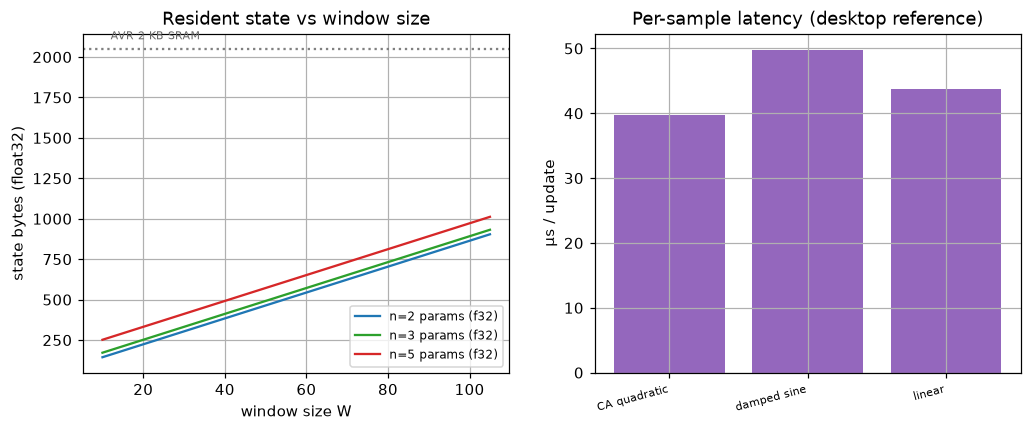

In [7]:
fig, (axa, axb) = plt.subplots(1, 2, figsize=(11, 4))
Ws = np.arange(10, 110, 5)
for nn, col in [(2, "tab:blue"), (3, "tab:green"), (5, "tab:red")]:
    axa.plot(Ws, [B.state_bytes(nn, ww, 4) for ww in Ws], "-", color=col,
             label=f"n={nn} params (f32)")
axa.axhline(2 * 1024, ls=":", color="0.5")
axa.text(12, 2 * 1024 * 1.03, "AVR 2 KB SRAM", fontsize=7, color="0.4")
axa.set_title("Resident state vs window size")
axa.set_xlabel("window size W"); axa.set_ylabel("state bytes (float32)")
axa.legend(fontsize=8)

axb.bar(range(len(B.CONFIGS)), [lat_by_cfg[c[0]] for c in B.CONFIGS], color="tab:purple")
axb.set_xticks(range(len(B.CONFIGS)))
axb.set_xticklabels([c[0].split(" (")[0] for c in B.CONFIGS], rotation=15,
                    fontsize=7, ha="right")
axb.set_title("Per-sample latency (desktop reference)")
axb.set_ylabel("µs / update")
fig.savefig(FIG / "footprint.png", dpi=110, bbox_inches="tight")
plt.show()

## Reading it

- **Memory is tiny and fixed.** A 3-axis GPS tracker needs sub-KB resident state — it fits
  comfortably on a Cortex-M0+/M4/ESP32 and is feasible even on a 2 KB AVR if that part is doing
  little else. Crucially the state does **not grow with the stream**, so there is no
  creeping-RAM failure mode.
- **Compute is never the bottleneck for GPS-rate data.** At a few thousand FLOPs per epoch and a
  1–10 Hz fix rate, even a soft-float MCU has orders of magnitude of headroom; the desktop path
  already runs each update in a few µs.
- **What you actually deploy is a C recurrence, not this code.** The Python/NumPy reference
  carries hundreds of KB of interpreter overhead that does not exist in a C port; the
  integration hot loops are already C (`dtfit._native`). For a *fixed* model (e.g. the CA
  quadratic) the model and Jacobian are trivial polynomials to hand-code, and the Kalman algebra
  is a handful of small fixed-size matrix ops — no dynamic allocation, no SymPy, no BLAS.
- **Versus the alternatives, the recursive estimators are the embeddable class.** dtfit's
  filters and the Kalman all carry fixed sub-KB state and adapt on-device; the Kalman is leanest
  (no window), dtfit pays one window buffer for its integral measurement, and the Legendre
  filter trades flash (constant projection tables) for observability without extra RAM. A batch
  fit / NN over the full history is the one that structurally does not fit (O(N) state); a small
  NN fits but cannot learn a new regime in the field.
- **float32 is the natural embedded choice** and halves the state; for these window sizes the
  integral/projection conditioning is benign enough that single precision is fine (unlike the
  batch GEMM throughput case in Exp 8, this is bounded-window, not a 10⁹-element reduction).
- **The honest caveat:** these are *projections* from a desktop-measured algorithm plus exact
  state-size arithmetic, not measurements on silicon. A real port would confirm the soft-float
  compute estimate and verify numerical behaviour at float32 on the target — but the memory
  verdict (small, fixed, fits) is exact and is the figure that usually decides embedded
  feasibility.